In [2]:
import torch
import torch.nn as nn
import os
from PIL import Image
import matplotlib.pyplot as plt
import random

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset

import sys
sys.path.append("..")

In [3]:
print(torch.__version__)

2.12.0+cpu


In [4]:
train_path = r"../data/inaturalist_12K/train"
val_path = r"../data/inaturalist_12K/val"

print(len(os.listdir(train_path)))
print(len(os.listdir(val_path)))

10
10


In [5]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

count = 0

for root, dirs, files in os.walk(val_path):
    for file in files:
        if file.endswith(image_extensions):
            count += 1

print("Total train images:", count)

Total train images: 2000


In [6]:
for cls in os.listdir(train_path):
    cls_path = os.path.join(train_path, cls)
    if os.path.isdir(cls_path):
        print(cls, len(os.listdir(cls_path)))

Amphibia 1000
Animalia 1000
Arachnida 1000
Aves 1000
Fungi 999
Insecta 1000
Mammalia 1000
Mollusca 1000
Plantae 1000
Reptilia 1000


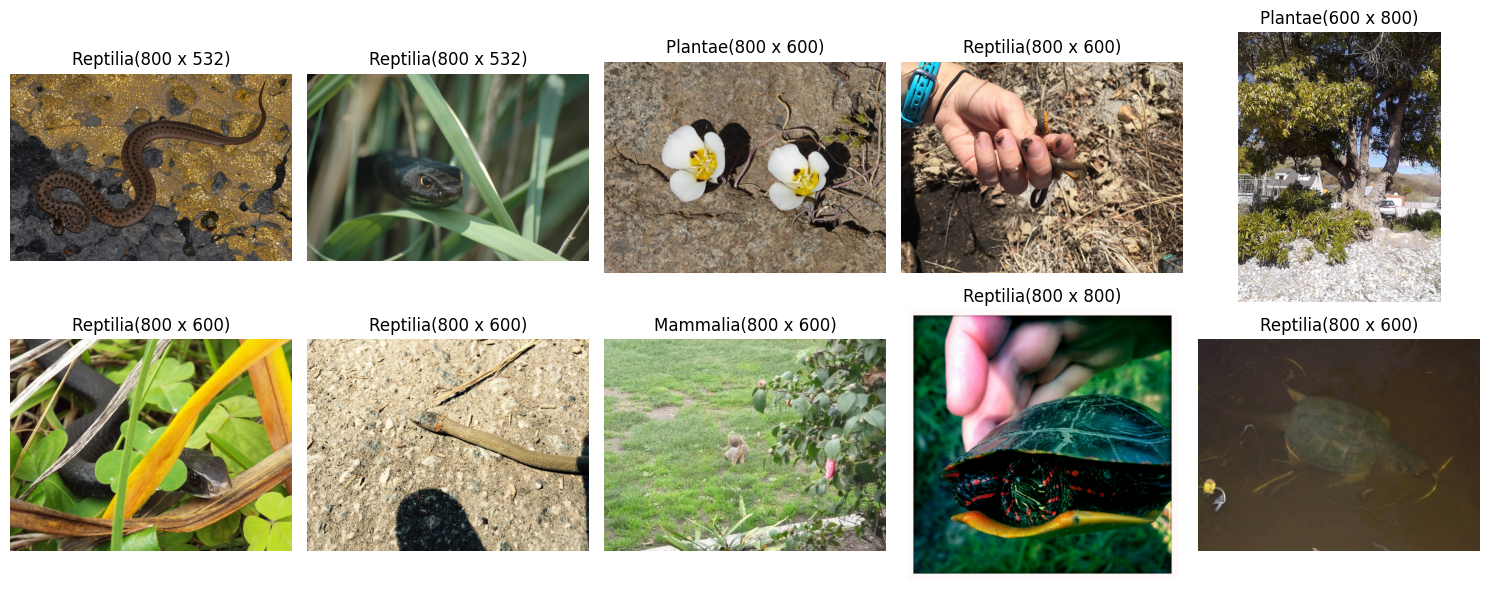

In [7]:
image_paths = []

for root, dirs, files in os.walk(train_path):
    for file in files:
        if file.endswith(image_extensions):
            image_paths.append(os.path.join(root,file))

# print(image_paths)

# 10 random images
example_imgs = random.sample(image_paths, 10)

fig, axes = plt.subplots(2,5, figsize = (15,6))

for ax, img_path in zip(axes.ravel(),example_imgs):
    img = Image.open(img_path)
    # img.show()
    ax.imshow(img)

    width, height = img.size
    
    cls_name = os.path.basename(os.path.dirname(img_path))

    title = cls_name + '(' + str(width) + ' x ' + str(height) + ')'
    ax.set_title(title)
    
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
min_w = float('inf')
max_w = 0
min_h = float('inf')
max_h = 0

for path in image_paths:
    with Image.open(path) as img:
        w, h = img.size

    min_w = min(min_w, w)
    max_w = max(max_w, w)
    min_h = min(min_h, h)
    max_h = max(max_h, h)

print(min_w, max_w)
print(min_h, max_h)

KeyboardInterrupt: 

In [9]:
# creating class to index

classes = sorted(os.listdir(train_path))

cls_to_idx = {}
for idx, cls in enumerate(classes):
    cls_to_idx[cls] = idx

cls_to_idx

{'Amphibia': 0,
 'Animalia': 1,
 'Arachnida': 2,
 'Aves': 3,
 'Fungi': 4,
 'Insecta': 5,
 'Mammalia': 6,
 'Mollusca': 7,
 'Plantae': 8,
 'Reptilia': 9}

In [10]:
# creating samples - tuple of image path and class index

samples = []

for root, dirs, files in os.walk(train_path):
    for file in files:
        if file.endswith(image_extensions):

            cls_name = os.path.basename(root)
            cls_idx = cls_to_idx[cls_name]
            samples.append((os.path.join(root,file), cls_idx))

len(samples)


9999

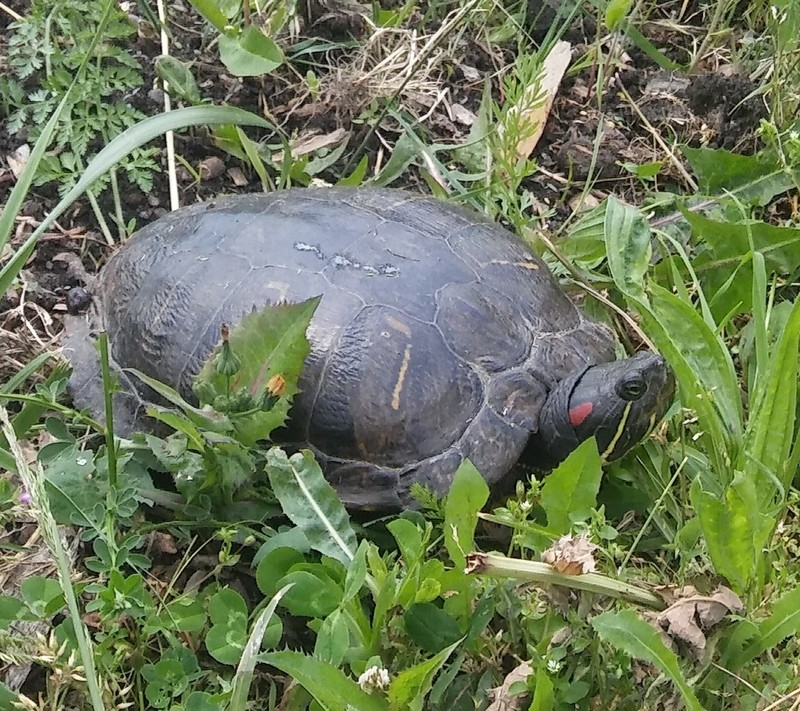

In [11]:
path, label = samples[9020]
Image.open(path)

In [12]:
# defining the transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def get_item(idx):
    path, label = samples[idx]

    img = Image.open(path)
    img = transform(img)

    return img, label

In [13]:
img, label = get_item(0)

print(type(img))
print(label)
img.shape

<class 'torch.Tensor'>
0


torch.Size([3, 224, 224])

In [14]:
class INaturalistDataset(Dataset):
    def __init__(self, train_path, transform = None):
        self.transform = transform
        
        self.cls_to_idx = {}

        # creating class to index
        classes = sorted(os.listdir(train_path))

        for idx, cls in enumerate(classes):
            self.cls_to_idx[cls] = idx

        self.samples = []
        for root, dirs, files in os.walk(train_path):
            for file in files:
                if file.endswith(image_extensions):

                    cls_name = os.path.basename(root)
                    cls_idx = self.cls_to_idx[cls_name]
                    self.samples.append((os.path.join(root,file), cls_idx))
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]

        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label
        

In [15]:
train_dataset = INaturalistDataset(train_path, transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


tensor([[[0.7922, 0.7765, 0.7647,  ..., 0.1725, 0.1843, 0.2039],
         [0.7804, 0.7961, 0.7961,  ..., 0.1725, 0.1765, 0.2000],
         [0.8353, 0.8157, 0.7804,  ..., 0.1490, 0.1098, 0.1412],
         ...,
         [0.6627, 0.6353, 0.6235,  ..., 0.3961, 0.5137, 0.5373],
         [0.6706, 0.6275, 0.6157,  ..., 0.4745, 0.4667, 0.5412],
         [0.6863, 0.6353, 0.6275,  ..., 0.5725, 0.5059, 0.5412]],

        [[0.6863, 0.6588, 0.6353,  ..., 0.1804, 0.1882, 0.2078],
         [0.6588, 0.6706, 0.6627,  ..., 0.1804, 0.1804, 0.2039],
         [0.7176, 0.6902, 0.6431,  ..., 0.1569, 0.1176, 0.1490],
         ...,
         [0.5961, 0.5647, 0.5490,  ..., 0.3686, 0.4706, 0.4824],
         [0.6000, 0.5569, 0.5373,  ..., 0.4549, 0.4314, 0.4980],
         [0.6196, 0.5647, 0.5490,  ..., 0.5529, 0.4784, 0.5098]],

        [[0.5608, 0.5412, 0.5216,  ..., 0.1216, 0.1255, 0.1373],
         [0.5490, 0.5490, 0.5412,  ..., 0.1255, 0.1216, 0.1373],
         [0.5961, 0.5569, 0.5216,  ..., 0.1098, 0.0706, 0.

In [17]:
from src.dataset import get_loaders

train_loader, val_loader, test_loader = get_loaders(
    train_path,
    val_path
)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])
